# Imports

In [1]:
import numpy as np              # Algebra lineal y numeros aleatorios
import pandas as pd             # Manipulacion de DataFrames
import joblib                   # Serializacion de modelos
import json                     # Lectura de artefactos (config, features)
import time                     # Medicion de tiempo de ejecucion
import os                       # Rutas y sistema de archivos
import sys                      # Informacion del sistema
import platform                 # Detalles del SO
import psutil                   # Monitoreo de recursos (CPU, RAM)
import warnings                 # Control de advertencias
import logging                  # Registro de eventos en archivo
import matplotlib.pyplot as plt   # Visualizacion estatica
import matplotlib.ticker as mticker  # Formateo de ejes
import seaborn as sns           # Visualizacion estadistica
from datetime import datetime   # Timestamps para logs
from copy import deepcopy       # Copia profunda de modelos
from sklearn.metrics import f1_score, fbeta_score  # Metricas (F1 apoyo, F2 decision)

warnings.filterwarnings('ignore')   # Silenciar warnings irrelevantes

# Estilo visual global
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42                        # Semilla para reproducibilidad
np.random.seed(SEED)             # Fijar semilla NumPy

# Rutas y Logger

In [5]:
BASE = os.path.dirname(os.path.abspath('.'))               # Directorio raiz del proyecto
NBK  = os.path.join(BASE, 'notebooks')                     # Carpeta de notebooks
S0   = os.path.join(NBK, 'outputs_sprint0', 'data')        # Datos base + indices del split
S2   = os.path.join(NBK, 'outputs_sprint2', 'data')        # Matrices de features (parquet)
S3M  = os.path.join(NBK, 'outputs_sprint3', 'models')      # Modelos calibrados del sprint 3
S3D  = os.path.join(NBK, 'outputs_sprint3', 'data')        # Features por modelo del sprint 3
S4   = os.path.join(NBK, 'outputs_sprint4')                # Artefactos del sprint 4 (campeon)
OUT_DIR = os.path.join(NBK, 'outputs_sprint4_latencia')    # Salidas de este benchmark
LOG_DIR = os.path.join(BASE, 'logs')                       # Logs del proyecto
os.makedirs(OUT_DIR, exist_ok=True)                        # Crear carpeta si no existe
os.makedirs(LOG_DIR, exist_ok=True)

# Configurar logger para evidencia del benchmark
log_path = os.path.join(LOG_DIR, 'benchmark_latencia.log')
logging.basicConfig(
    filename=log_path,
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger('benchmark')
logger.info('='*60)
logger.info('INICIO BENCHMARK DE LATENCIA')
logger.info(f'Fecha: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

print(f'Log de benchmark: {log_path}')
print(f'Directorio de salida: {OUT_DIR}')

Log de benchmark: /workspaces/proyecto-zona-interes-Au/logs/benchmark_latencia.log
Directorio de salida: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint4_latencia


# Información del sistema

In [6]:
sys_info = {
    'OS': platform.platform(),
    'Python': platform.python_version(),
    'CPU': platform.processor() or 'N/A',
    'CPU cores (logicos)': psutil.cpu_count(logical=True),
    'CPU cores (fisicos)': psutil.cpu_count(logical=False),
    'RAM total (GB)': f'{psutil.virtual_memory().total / (1024**3):.1f}',
    'RAM disponible (GB)': f'{psutil.virtual_memory().available / (1024**3):.1f}',
}

# Verificar GPU
HAS_GPU = False
try:
    import subprocess
    gpu_info = subprocess.check_output(
        ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
        text=True
    ).strip()
    sys_info['GPU'] = gpu_info
    HAS_GPU = True
except Exception:
    sys_info['GPU'] = 'No disponible'
    HAS_GPU = False

print('=== INFORMACION DEL SISTEMA ===')
for k, v in sys_info.items():
    print(f'  {k}: {v}')
    logger.info(f'SISTEMA | {k}: {v}')

=== INFORMACION DEL SISTEMA ===
  OS: Linux-6.8.0-1052-azure-x86_64-with-glibc2.39
  Python: 3.12.1
  CPU: x86_64
  CPU cores (logicos): 2
  CPU cores (fisicos): 1
  RAM total (GB): 7.8
  RAM disponible (GB): 1.7
  GPU: No disponible


# Carga de datos y modelos

In [7]:
# Datos hold-out (mismo split del sprint 0/2): set E3 = superconjunto que contiene las features de ambos modelos
X_test_full = pd.read_parquet(os.path.join(S2, 'X_E3_test.parquet'))
df_raw = pd.read_csv(os.path.join(S0, 'data_procesada.csv'))
idx_test = np.load(os.path.join(S0, 'idx_test.npy'))
y_test = df_raw.loc[idx_test, 'target_Au'].reset_index(drop=True)

FEATS = json.load(open(os.path.join(S3D, 'features_s3_por_modelo.json')))
THRESHOLD_FINAL = json.load(open(os.path.join(S4, 'resumen_sprint4.json')))['calibracion_umbral']['umbral_global_nested']
fx, fr = FEATS['XGBoost'], FEATS['Random Forest']

# Modelos FINALES calibrados (autocontenidos: escalan internamente, reciben features CRUDAS)
model_xgb = joblib.load(os.path.join(S4, 'models', 'modelo_campeon_final.pkl'))     # campeon (XGBoost calibrado)
model_rf  = joblib.load(os.path.join(S3M, 'modelo_calibrado_random_forest.pkl'))    # RF calibrado (referencia)

# Features crudas para los modelos calibrados (float32 para el benchmark)
X_test_xgb = X_test_full[fx].to_numpy(dtype=np.float32)   # 28 features del campeon
X_test_rf  = X_test_full[fr].to_numpy(dtype=np.float32)   # features del RF

# Core de arboles (para conversion a ONNX) extraido del pipeline calibrado + su StandardScaler.
# El campeon envuelve varios pipelines (uno por fold de calibracion); tomamos el fold 0 como
# representante del NUCLEO de inferencia (el ensemble de arboles es la parte optimizable con ONNX).
def _extraer_core(cal_model):
    est = cal_model.calibrated_classifiers_[0].estimator
    return est.named_steps['sc'], est.named_steps['clf']
sc_xgb, xgb_core = _extraer_core(model_xgb)
sc_rf,  rf_core  = _extraer_core(model_rf)
X_test_xgb_scaled = sc_xgb.transform(X_test_full[fx]).astype(np.float32)   # entrada al core XGB / ONNX
X_test_rf_scaled  = sc_rf.transform(X_test_full[fr]).astype(np.float32)    # entrada al core RF / ONNX

print(f'Hold-out: {X_test_full.shape[0]} muestras | XGB={len(fx)} feats | RF={len(fr)} feats')
print(f'Campeon: {type(model_xgb).__name__} ({len(model_xgb.calibrated_classifiers_)} folds de calibracion) | core XGB={xgb_core.n_estimators} arboles, depth={xgb_core.max_depth}')
print(f'RF calibrado: core={rf_core.n_estimators} arboles')
print(f'Umbral de decision final (metrica F2): {THRESHOLD_FINAL:.4f}')
logger.info(f'DATOS | Test: {X_test_full.shape} | XGB feats={len(fx)} RF feats={len(fr)}')
logger.info(f'MODELO | Campeon calibrado (core XGB n_est={xgb_core.n_estimators}, depth={xgb_core.max_depth})')

Hold-out: 427 muestras | XGB=28 feats | RF=39 feats
Campeon: CalibratedClassifierCV (5 folds de calibracion) | core XGB=52 arboles, depth=9
RF calibrado: core=88 arboles
Umbral de decision final (metrica F2): 0.1842


# Función de Benchmark de latencia

In [8]:
def benchmark_latencia(predict_fn, X, batch_sizes=[1, 8, 32, 128], n_reps=1000, warmup=50, nombre='modelo'):
    """
    Benchmark de latencia para una funcion de prediccion.

    Args:
        predict_fn: funcion que recibe X y retorna predicciones
        X: datos de entrada (numpy array)
        batch_sizes: tamanos de batch a evaluar
        n_reps: numero de repeticiones por medicion
        warmup: repeticiones de calentamiento (descartadas)
        nombre: nombre del modelo para logging

    Returns:
        DataFrame con metricas de latencia por batch size
    """
    resultados = []

    for bs in batch_sizes:
        # Seleccionar datos del batch
        X_batch = X[:bs] if bs <= len(X) else X
        actual_bs = len(X_batch)

        # Warmup: calentar caches antes de medir
        for _ in range(warmup):
            _ = predict_fn(X_batch)

        # Medicion: n_reps repeticiones
        latencias = []
        for _ in range(n_reps):
            t0 = time.perf_counter()
            _ = predict_fn(X_batch)
            t1 = time.perf_counter()
            latencias.append((t1 - t0) * 1000)  # convertir a milisegundos

        latencias = np.array(latencias)

        result = {
            'Modelo': nombre,
            'Batch_Size': actual_bs,
            'Latencia_p50_ms': np.percentile(latencias, 50),
            'Latencia_p95_ms': np.percentile(latencias, 95),
            'Latencia_p99_ms': np.percentile(latencias, 99),
            'Latencia_mean_ms': np.mean(latencias),
            'Latencia_std_ms': np.std(latencias),
            'Latencia_min_ms': np.min(latencias),
            'Latencia_max_ms': np.max(latencias),
            'Throughput_req_s': actual_bs / (np.mean(latencias) / 1000),
            'Latencia_por_muestra_ms': np.percentile(latencias, 50) / actual_bs,
        }
        resultados.append(result)

        logger.info(f'LATENCIA | {nombre} | batch={actual_bs} | '
                    f'p50={result["Latencia_p50_ms"]:.3f}ms | '
                    f'p95={result["Latencia_p95_ms"]:.3f}ms | '
                    f'throughput={result["Throughput_req_s"]:.0f} req/s')

        print(f'  batch={actual_bs:>4d} | p50={result["Latencia_p50_ms"]:8.3f}ms | '
              f'p95={result["Latencia_p95_ms"]:8.3f}ms | '
              f'throughput={result["Throughput_req_s"]:>10.0f} req/s')

    return pd.DataFrame(resultados)

print('Funcion benchmark_latencia() definida')

Funcion benchmark_latencia() definida


# Benchmark Sklearn (CPU) - Campeón calibrado, RF calibrado y core XGBoost

In [9]:
BATCH_SIZES = [1, 8, 32, 128, 427]
N_REPS = 1000

# --- Campeon: XGBoost calibrado (extremo a extremo, features crudas) ---
print('=== XGBoost campeon (calibrado, sklearn CPU) ===')
mem_before = psutil.Process().memory_info().rss / (1024**2)
df_lat_champ = benchmark_latencia(
    predict_fn=lambda X: model_xgb.predict_proba(X),
    X=X_test_xgb, batch_sizes=BATCH_SIZES, n_reps=N_REPS,
    nombre='XGBoost_campeon_sklearn'
)
mem_after = psutil.Process().memory_info().rss / (1024**2)
print(f'\nMemoria RSS: {mem_before:.1f} MB -> {mem_after:.1f} MB (Delta={mem_after-mem_before:+.1f} MB)')
logger.info(f'MEMORIA | Campeon calibrado | RSS: {mem_before:.1f} -> {mem_after:.1f} MB')

# --- Random Forest calibrado (extremo a extremo, features crudas) ---
print('=== Random Forest (calibrado, sklearn CPU) ===')
mem_before = psutil.Process().memory_info().rss / (1024**2)
df_lat_rf = benchmark_latencia(
    predict_fn=lambda X: model_rf.predict_proba(X),
    X=X_test_rf, batch_sizes=BATCH_SIZES, n_reps=N_REPS,
    nombre='RF_calibrado_sklearn'
)
mem_after = psutil.Process().memory_info().rss / (1024**2)
print(f'\nMemoria RSS: {mem_before:.1f} MB -> {mem_after:.1f} MB (Delta={mem_after-mem_before:+.1f} MB)')
logger.info(f'MEMORIA | RF calibrado | RSS: {mem_before:.1f} -> {mem_after:.1f} MB')

# --- Core de arboles del campeon (sklearn): linea base para la comparativa contra ONNX ---
print('=== XGBoost core del campeon (sklearn CPU) ===')
df_lat_xgb_core = benchmark_latencia(
    predict_fn=lambda X: xgb_core.predict_proba(X),
    X=X_test_xgb_scaled, batch_sizes=BATCH_SIZES, n_reps=N_REPS,
    nombre='XGBoost_core_sklearn'
)

=== XGBoost campeon (calibrado, sklearn CPU) ===
  batch=   1 | p50=   6.999ms | p95=  17.396ms | throughput=       109 req/s
  batch=   8 | p50=   7.180ms | p95=  19.035ms | throughput=       824 req/s
  batch=  32 | p50=   7.546ms | p95=  37.106ms | throughput=      2402 req/s
  batch= 128 | p50=   8.344ms | p95=  73.254ms | throughput=      6782 req/s
  batch= 427 | p50=  10.028ms | p95=  46.850ms | throughput=     23729 req/s

Memoria RSS: 324.0 MB -> 325.3 MB (Delta=+1.3 MB)
=== Random Forest (calibrado, sklearn CPU) ===
  batch=   1 | p50= 120.314ms | p95= 195.832ms | throughput=         7 req/s
  batch=   8 | p50= 119.130ms | p95= 159.265ms | throughput=        63 req/s
  batch=  32 | p50= 119.371ms | p95= 161.741ms | throughput=       254 req/s
  batch= 128 | p50= 121.664ms | p95= 258.860ms | throughput=       879 req/s
  batch= 427 | p50= 120.178ms | p95= 165.227ms | throughput=      3299 req/s

Memoria RSS: 325.3 MB -> 255.2 MB (Delta=-70.1 MB)
=== XGBoost core del campeon (s

# Conversión a ONNX y Benchmark

In [10]:
# Por que ONNX y no TensorRT/torch.compile?
# - TensorRT: disenado para redes neuronales (CNN, Transformers). No aplica
#   directamente a modelos de arboles (XGBoost/RF).
# - torch.compile: requiere modelos PyTorch. XGBoost/sklearn no son PyTorch.
# - ONNX Runtime: soporta nativamente arboles de decision y ensemble methods.
#   Es la optimizacion estandar para XGBoost/sklearn en produccion.
#
# NOTA: el campeon es un CalibratedClassifierCV (isotonica, 5 folds) sobre un pipeline
# StandardScaler -> SMOTE -> XGBoost. La capa de calibracion no es convertible de forma
# directa a ONNX; por ello se optimiza y mide el NUCLEO de inferencia (el ensemble de
# arboles XGBoost), que es la parte pesada en computo. El StandardScaler se aplica antes
# de la sesion ONNX (equivalente a como opera dentro del pipeline).

from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType
import onnxruntime as ort

print('=== Conversion del core XGBoost (campeon) a ONNX ===')
n_features = X_test_xgb_scaled.shape[1]

# Convertir el core de arboles del campeon a formato ONNX
initial_type = [('float_input', FloatTensorType([None, n_features]))]
onnx_model_xgb = convert_xgboost(xgb_core, initial_types=initial_type)

# Guardar modelo ONNX
onnx_path_xgb = os.path.join(OUT_DIR, 'xgboost_optuna.onnx')
with open(onnx_path_xgb, 'wb') as f:
    f.write(onnx_model_xgb.SerializeToString())

onnx_size = os.path.getsize(onnx_path_xgb) / 1024
pkl_size = os.path.getsize(os.path.join(S4, 'models', 'modelo_campeon_final.pkl')) / 1024
print(f'Campeon .pkl (calibrado completo): {pkl_size:.1f} KB')
print(f'Core XGBoost .onnx:                {onnx_size:.1f} KB')
logger.info(f'ONNX | core XGBoost convertido: {onnx_size:.1f}KB (pkl campeon {pkl_size:.1f}KB)')

# Crear sesion ONNX Runtime (single-thread para medicion justa)
sess_options = ort.SessionOptions()
sess_options.intra_op_num_threads = 1
sess_xgb_onnx = ort.InferenceSession(onnx_path_xgb, sess_options)
input_name = sess_xgb_onnx.get_inputs()[0].name

# Verificar equivalencia numerica entre el core sklearn y ONNX
X_sample = X_test_xgb_scaled[:10]
onnx_pred = sess_xgb_onnx.run(None, {input_name: X_sample})
sklearn_probs = xgb_core.predict_proba(X_sample)[:, 1]
_raw = onnx_pred[1]
onnx_probs = np.array([p[1] for p in _raw]) if isinstance(_raw, list) else np.asarray(_raw)[:, 1]
max_diff = float(np.max(np.abs(onnx_probs - sklearn_probs)))
print(f'\nVerificacion de equivalencia core sklearn vs ONNX (max diff): {max_diff:.8f}')
print(f'Equivalencia OK: {max_diff < 1e-4}')
logger.info(f'ONNX | Verificacion equivalencia core: max_diff={max_diff:.8f}')

# --- Benchmark ONNX single-thread ---
print('=== XGBoost core ONNX Runtime (CPU) ===')
mem_before = psutil.Process().memory_info().rss / (1024**2)

def predict_onnx(X):
    return sess_xgb_onnx.run(None, {input_name: X.astype(np.float32)})

df_lat_onnx = benchmark_latencia(
    predict_fn=predict_onnx,
    X=X_test_xgb_scaled,
    batch_sizes=BATCH_SIZES,
    n_reps=N_REPS,
    nombre='XGBoost_core_ONNX'
)

mem_after = psutil.Process().memory_info().rss / (1024**2)
print(f'\nMemoria RSS: {mem_before:.1f} MB -> {mem_after:.1f} MB (Delta={mem_after-mem_before:+.1f} MB)')
logger.info(f'MEMORIA | ONNX Runtime | RSS: {mem_before:.1f} -> {mem_after:.1f} MB')

# --- Benchmark ONNX multi-thread ---
print('=== XGBoost core ONNX Runtime (CPU, multi-thread) ===')
n_threads = psutil.cpu_count(logical=True)
print(f'Usando {n_threads} threads\n')

sess_options_mt = ort.SessionOptions()
sess_options_mt.intra_op_num_threads = n_threads
sess_xgb_onnx_mt = ort.InferenceSession(onnx_path_xgb, sess_options_mt)
input_name_mt = sess_xgb_onnx_mt.get_inputs()[0].name

def predict_onnx_mt(X):
    return sess_xgb_onnx_mt.run(None, {input_name_mt: X.astype(np.float32)})

df_lat_onnx_mt = benchmark_latencia(
    predict_fn=predict_onnx_mt,
    X=X_test_xgb_scaled,
    batch_sizes=BATCH_SIZES,
    n_reps=N_REPS,
    nombre=f'XGBoost_core_ONNX_{n_threads}t'
)

2026-07-31 22:08:51.476012513 [W:onnxruntime:Default, device_discovery.cc:133 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/PNP0A03:00/device:07/VMBUS:01/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename "5620e0c7-8062-4dce-aeb7-520c7ef76171" did not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+


=== Conversion del core XGBoost (campeon) a ONNX ===
Campeon .pkl (calibrado completo): 1166.1 KB
Core XGBoost .onnx:                136.2 KB

Verificacion de equivalencia core sklearn vs ONNX (max diff): 0.00000009
Equivalencia OK: True
=== XGBoost core ONNX Runtime (CPU) ===
  batch=   1 | p50=   0.012ms | p95=   0.013ms | throughput=     85036 req/s
  batch=   8 | p50=   0.014ms | p95=   0.016ms | throughput=    534610 req/s
  batch=  32 | p50=   0.031ms | p95=   0.053ms | throughput=    938557 req/s
  batch= 128 | p50=   0.150ms | p95=   0.247ms | throughput=    765469 req/s
  batch= 427 | p50=   0.968ms | p95=   1.744ms | throughput=    372779 req/s

Memoria RSS: 286.7 MB -> 286.7 MB (Delta=+0.0 MB)
=== XGBoost core ONNX Runtime (CPU, multi-thread) ===
Usando 2 threads

  batch=   1 | p50=   0.011ms | p95=   0.014ms | throughput=     39740 req/s
  batch=   8 | p50=   0.021ms | p95=   0.031ms | throughput=    296813 req/s
  batch=  32 | p50=   0.053ms | p95=   0.084ms | throughput=

# Conversión RF a ONNX

In [11]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType as FloatTensorTypeSKL

print('=== Conversion del core Random Forest a ONNX ===')
n_features_rf = X_test_rf_scaled.shape[1]
initial_type_rf = [('float_input', FloatTensorTypeSKL([None, n_features_rf]))]
onnx_model_rf = convert_sklearn(rf_core, initial_types=initial_type_rf,
                                options={id(rf_core): {'zipmap': False}})

onnx_path_rf = os.path.join(OUT_DIR, 'rf_baseline_fe.onnx')
with open(onnx_path_rf, 'wb') as f:
    f.write(onnx_model_rf.SerializeToString())

onnx_size_rf = os.path.getsize(onnx_path_rf) / 1024
pkl_size_rf = os.path.getsize(os.path.join(S3M, 'modelo_calibrado_random_forest.pkl')) / 1024
print(f'RF calibrado .pkl: {pkl_size_rf:.1f} KB')
print(f'Core RF .onnx:     {onnx_size_rf:.1f} KB')

# Sesion y benchmark RF ONNX
sess_rf_onnx = ort.InferenceSession(onnx_path_rf, sess_options)
input_name_rf = sess_rf_onnx.get_inputs()[0].name

# Verificacion de equivalencia
_probs_rf_sk = rf_core.predict_proba(X_test_rf_scaled[:10])[:, 1]
_out_rf = sess_rf_onnx.run(None, {input_name_rf: X_test_rf_scaled[:10]})
_probs_rf_ox = np.asarray(_out_rf[1])[:, 1]
print(f'Equivalencia core RF sklearn vs ONNX (max diff): {float(np.max(np.abs(_probs_rf_ox - _probs_rf_sk))):.8f}')

print('\n=== Random Forest core ONNX Runtime (CPU) ===')
df_lat_rf_onnx = benchmark_latencia(
    predict_fn=lambda X: sess_rf_onnx.run(None, {input_name_rf: X.astype(np.float32)}),
    X=X_test_rf_scaled,
    batch_sizes=BATCH_SIZES,
    n_reps=N_REPS,
    nombre='RF_core_ONNX'
)
logger.info(f'ONNX | RF core convertido: {pkl_size_rf:.1f}KB -> {onnx_size_rf:.1f}KB')

=== Conversion del core Random Forest a ONNX ===
RF calibrado .pkl: 4338.5 KB
Core RF .onnx:     341.5 KB
Equivalencia core RF sklearn vs ONNX (max diff): 0.00000003

=== Random Forest core ONNX Runtime (CPU) ===
  batch=   1 | p50=   0.009ms | p95=   0.009ms | throughput=    112811 req/s
  batch=   8 | p50=   0.020ms | p95=   0.034ms | throughput=    345945 req/s
  batch=  32 | p50=   0.049ms | p95=   0.088ms | throughput=    526535 req/s
  batch= 128 | p50=   0.405ms | p95=   0.629ms | throughput=    270111 req/s
  batch= 427 | p50=   2.081ms | p95=   4.076ms | throughput=    188040 req/s


# Tabla comparativa

In [12]:
# Consolidar todos los resultados de latencia
df_all = pd.concat([df_lat_champ, df_lat_rf, df_lat_xgb_core, df_lat_onnx, df_lat_onnx_mt, df_lat_rf_onnx],
                   ignore_index=True)
df_all.to_csv(os.path.join(OUT_DIR, 'benchmark_latencia_completo.csv'), index=False)

print('=== TABLA COMPARATIVA COMPLETA ===')
display_cols = ['Modelo', 'Batch_Size', 'Latencia_p50_ms', 'Latencia_p95_ms',
                'Throughput_req_s', 'Latencia_por_muestra_ms']
print(df_all[display_cols].round(3).to_string(index=False))

# Tabla resumen: comparativa para batch=1 y batch=427 (casos extremos)
modelos_comp = ['XGBoost_campeon_sklearn', 'XGBoost_core_sklearn', 'XGBoost_core_ONNX',
                'RF_calibrado_sklearn', 'RF_core_ONNX']

print('\n=== RESUMEN COMPARATIVO (batch=1 y batch=427) ===')
resumen = []
for bs in [1, 427]:
    for mod in modelos_comp:
        row = df_all[(df_all['Modelo'] == mod) & (df_all['Batch_Size'] == bs)]
        if not row.empty:
            r = row.iloc[0]
            resumen.append({
                'Motor': mod,
                'Batch': bs,
                'p50 (ms)': f"{r['Latencia_p50_ms']:.3f}",
                'p95 (ms)': f"{r['Latencia_p95_ms']:.3f}",
                'Throughput (req/s)': f"{r['Throughput_req_s']:.0f}",
                'ms/muestra': f"{r['Latencia_por_muestra_ms']:.4f}",
            })

df_resumen = pd.DataFrame(resumen)
df_resumen.to_csv(os.path.join(OUT_DIR, 'resumen_comparativo.csv'), index=False)
print(df_resumen.to_string(index=False))

# Speedup ONNX vs sklearn (core vs core, comparacion justa del mismo ensemble de arboles)
print('\n=== SPEEDUP ONNX vs SKLEARN (core XGBoost) ===')
for bs in BATCH_SIZES:
    xgb_sk = df_all[(df_all['Modelo']=='XGBoost_core_sklearn') & (df_all['Batch_Size']==bs)]['Latencia_p50_ms'].values
    xgb_ox = df_all[(df_all['Modelo']=='XGBoost_core_ONNX') & (df_all['Batch_Size']==bs)]['Latencia_p50_ms'].values
    if len(xgb_sk) > 0 and len(xgb_ox) > 0:
        speedup = xgb_sk[0] / xgb_ox[0]
        print(f'  Batch {bs:>4d}: sklearn={xgb_sk[0]:.3f}ms -> ONNX={xgb_ox[0]:.3f}ms | Speedup: {speedup:.2f}x')
        logger.info(f'SPEEDUP | batch={bs} | core sklearn={xgb_sk[0]:.3f}ms -> ONNX={xgb_ox[0]:.3f}ms | {speedup:.2f}x')

=== TABLA COMPARATIVA COMPLETA ===
                 Modelo  Batch_Size  Latencia_p50_ms  Latencia_p95_ms  Throughput_req_s  Latencia_por_muestra_ms
XGBoost_campeon_sklearn           1            6.999           17.396           109.292                    6.999
XGBoost_campeon_sklearn           8            7.180           19.035           823.533                    0.898
XGBoost_campeon_sklearn          32            7.546           37.106          2402.305                    0.236
XGBoost_campeon_sklearn         128            8.344           73.254          6781.889                    0.065
XGBoost_campeon_sklearn         427           10.028           46.850         23729.425                    0.023
   RF_calibrado_sklearn           1          120.314          195.832             7.422                  120.314
   RF_calibrado_sklearn           8          119.130          159.265            63.304                   14.891
   RF_calibrado_sklearn          32          119.371         

# Ratio de errores con inputs corruptos

In [18]:
print('=== TEST DE ROBUSTEZ - RATIO DE ERRORES ===')

test_cases = {
    'Normal': X_test_xgb.copy(),
    'Con NaN (5%)': None,
    'Con NaN (20%)': None,
    'Con Inf': None,
    'Valores extremos (x100)': X_test_xgb.copy() * 100,
    'Todo ceros': np.zeros_like(X_test_xgb),
}

# Crear inputs corruptos
X_nan5 = X_test_xgb.copy()
mask5 = np.random.random(X_nan5.shape) < 0.05
X_nan5[mask5] = np.nan
test_cases['Con NaN (5%)'] = X_nan5

X_nan20 = X_test_xgb.copy()
mask20 = np.random.random(X_nan20.shape) < 0.20
X_nan20[mask20] = np.nan
test_cases['Con NaN (20%)'] = X_nan20

X_inf = X_test_xgb.copy()
X_inf[0, 0] = np.inf
X_inf[1, 1] = -np.inf
test_cases['Con Inf'] = X_inf

error_results = []
for case_name, X_case in test_cases.items():
    n_total = len(X_case)
    n_errores = 0
    n_exitosos = 0

    try:
        y_pred = model_xgb.predict(X_case)
        y_prob = model_xgb.predict_proba(X_case)[:, 1]
        # Verificar si las predicciones son validas
        n_nan_pred = np.isnan(y_prob).sum()
        n_exitosos = n_total - n_nan_pred
        n_errores = n_nan_pred
        status = 'OK' if n_errores == 0 else f'Atencion: {n_errores} NaN'
    except Exception as e:
        n_errores = n_total
        n_exitosos = 0
        status = f'Error: {str(e)[:50]}'

    ratio = n_errores / n_total
    error_results.append({
        'Caso': case_name,
        'Total': n_total,
        'Exitosos': n_exitosos,
        'Errores': n_errores,
        'Ratio Error (%)': f'{ratio:.2%}',
        'Status': status
    })
    print(f'  {case_name:25s} | errores={n_errores:>4d}/{n_total} ({ratio:.2%}) | {status}')
    logger.info(f'ROBUSTEZ | {case_name} | errores={n_errores}/{n_total} ({ratio:.2%}) | {status}')

df_errores = pd.DataFrame(error_results)
df_errores.to_csv(os.path.join(OUT_DIR, 'ratio_errores.csv'), index=False)
print('\nGuardado: ratio_errores.csv')

=== TEST DE ROBUSTEZ - RATIO DE ERRORES ===
  Normal                    | errores=   0/427 (0.00%) | OK
  Con NaN (5%)              | errores=   0/427 (0.00%) | OK
  Con NaN (20%)             | errores=   0/427 (0.00%) | OK
  Con Inf                   | errores= 427/427 (100.00%) | Error: Input X contains infinity or a value too large for
  Valores extremos (x100)   | errores=   0/427 (0.00%) | OK
  Todo ceros                | errores=   0/427 (0.00%) | OK

Guardado: ratio_errores.csv


# Visualizaciones

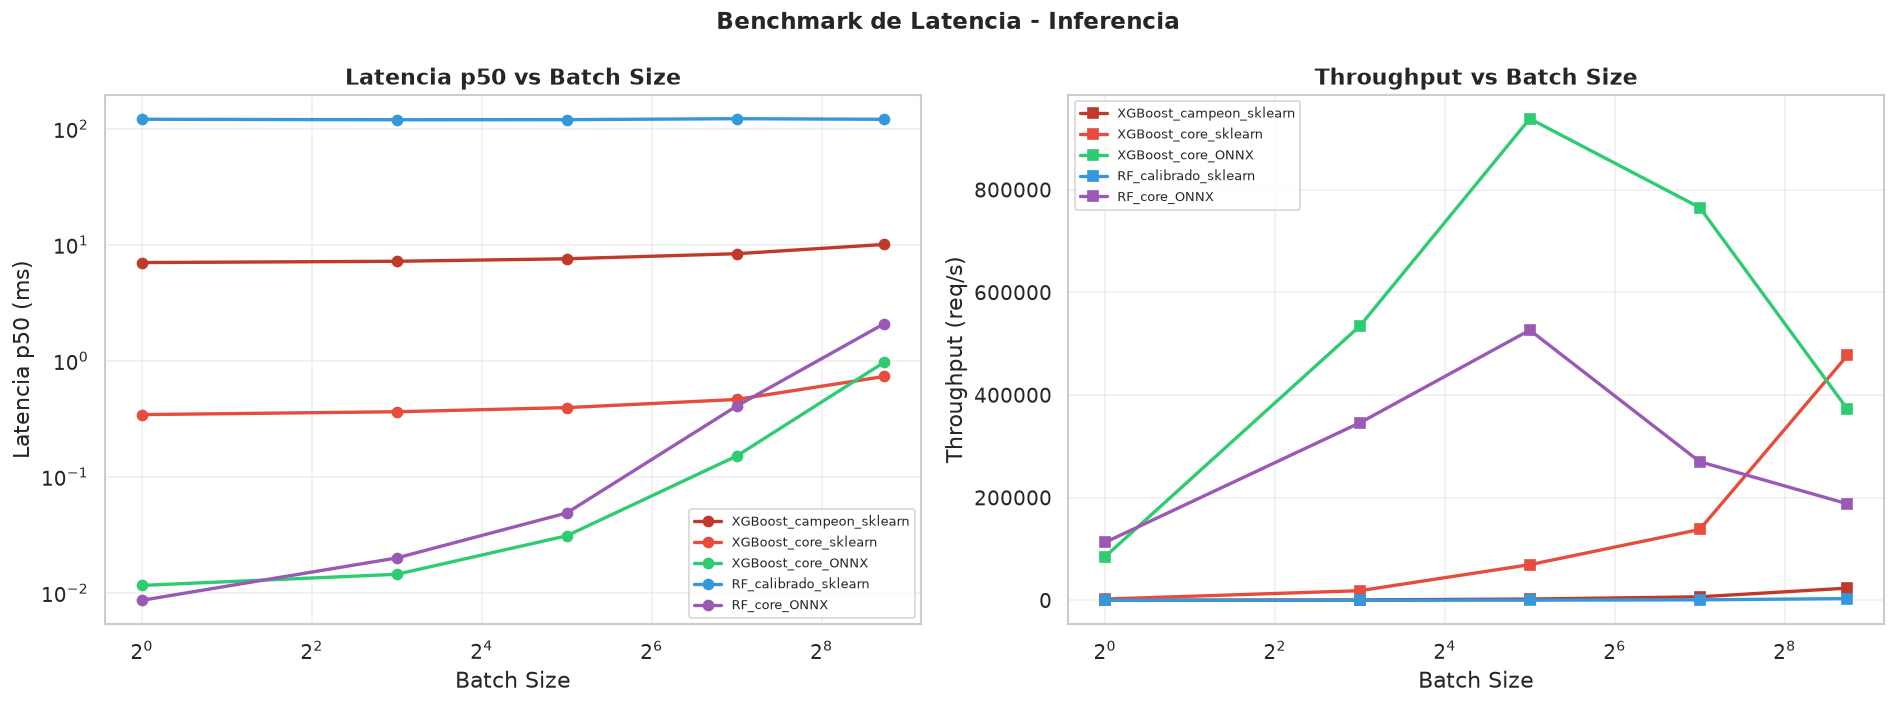

Guardado: latencia_throughput.png


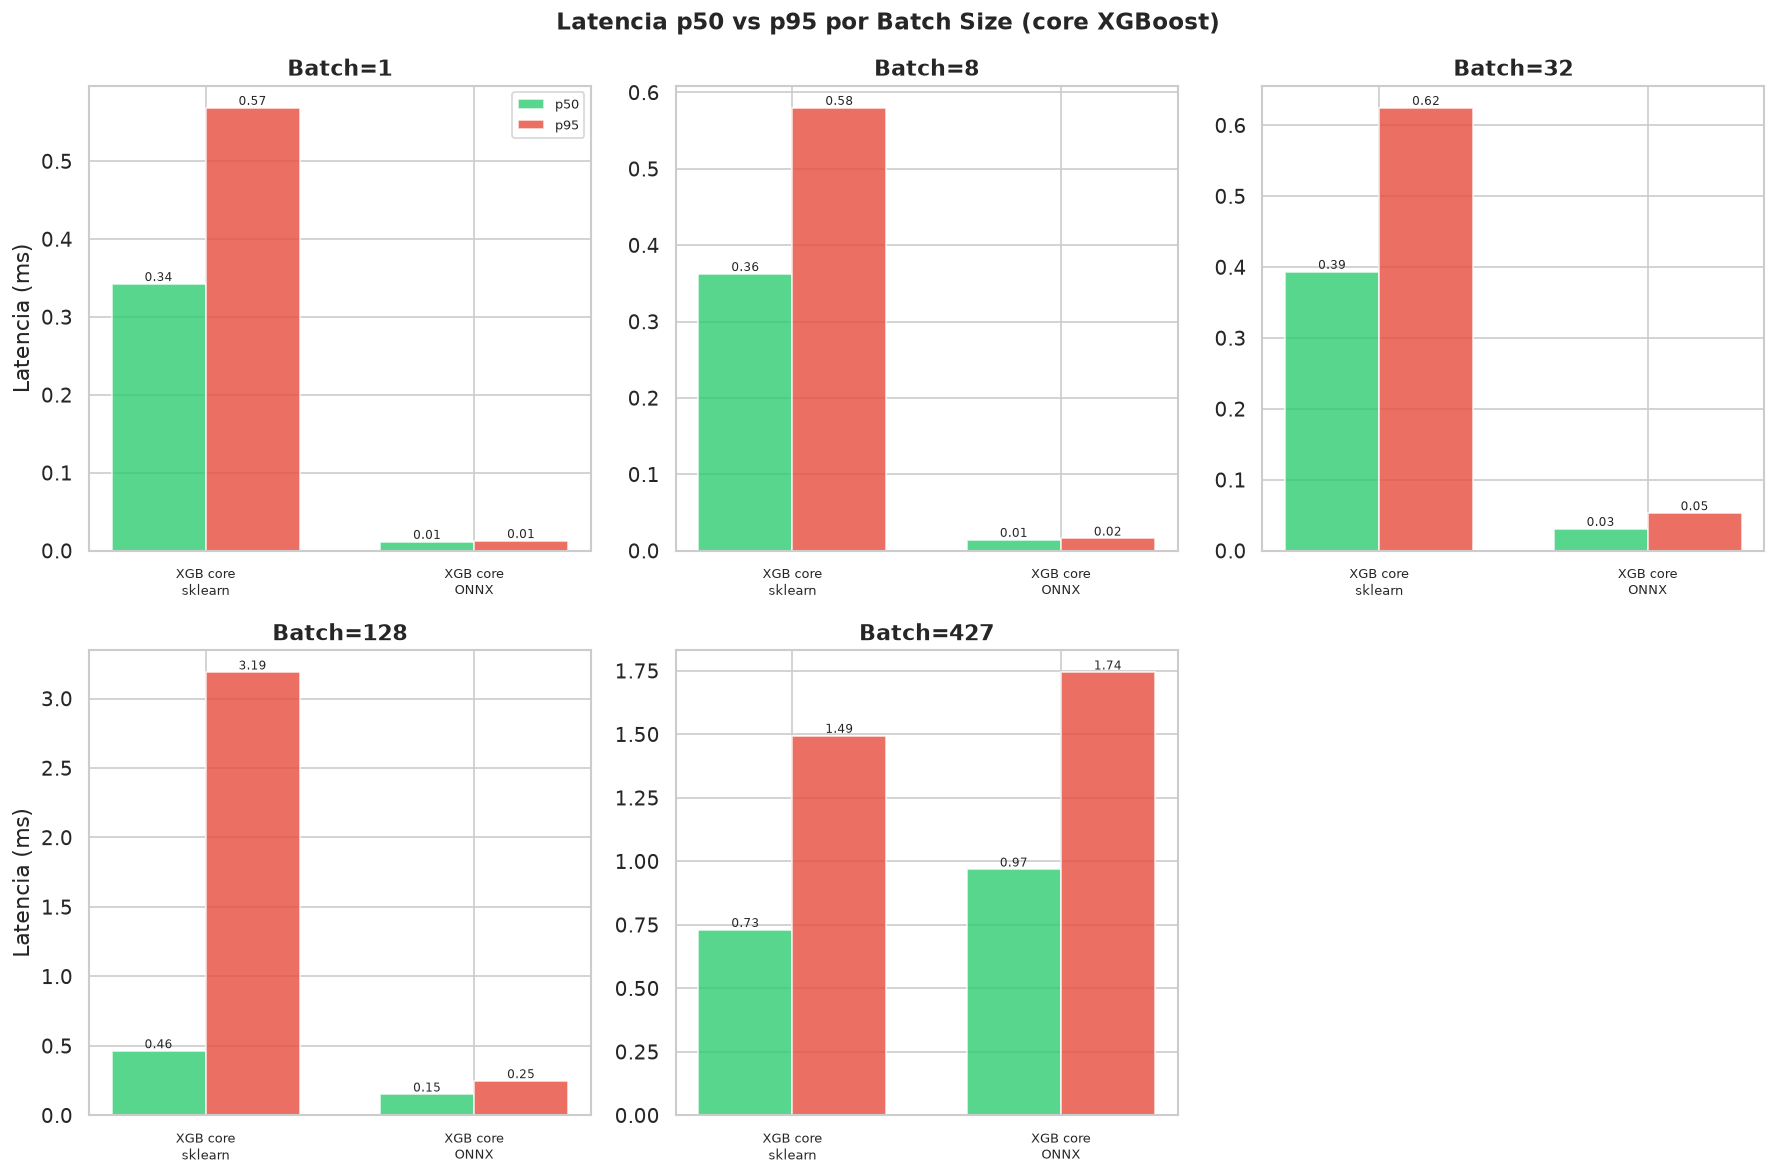

Guardado: latencia_p50_p95_barras.png


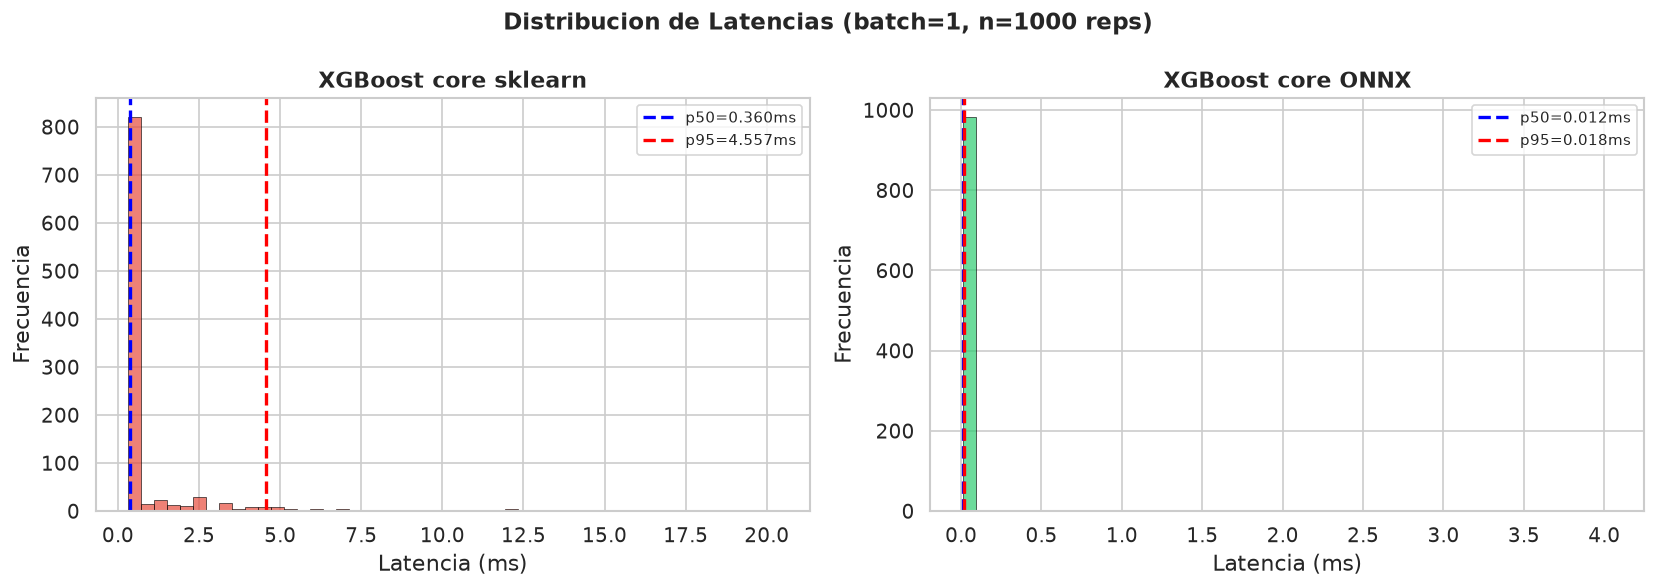

Guardado: distribucion_latencias.png


In [13]:
# 11.1 Latencia p50 por batch size (motores principales)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Benchmark de Latencia - Inferencia', fontsize=14, fontweight='bold')

colores_motor = {
    'XGBoost_campeon_sklearn': '#c0392b',
    'XGBoost_core_sklearn': '#e74c3c',
    'XGBoost_core_ONNX': '#2ecc71',
    'RF_calibrado_sklearn': '#3498db',
    'RF_core_ONNX': '#9b59b6',
}

for motor, color in colores_motor.items():
    df_m = df_all[df_all['Modelo'] == motor]
    if not df_m.empty:
        ax1.plot(df_m['Batch_Size'], df_m['Latencia_p50_ms'], 'o-', color=color, label=motor, linewidth=2)
        ax2.plot(df_m['Batch_Size'], df_m['Throughput_req_s'], 's-', color=color, label=motor, linewidth=2)

ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Latencia p50 (ms)')
ax1.set_title('Latencia p50 vs Batch Size', fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Throughput (req/s)')
ax2.set_title('Throughput vs Batch Size', fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_xscale('log', base=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'latencia_throughput.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: latencia_throughput.png')

# 11.2 Comparativa p50 vs p95 (core XGBoost: sklearn vs ONNX)
n = len(BATCH_SIZES)
n_cols = (n + 1) // 2
fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 10), sharey=False)
axes = axes.flatten()
fig.suptitle('Latencia p50 vs p95 por Batch Size (core XGBoost)', fontsize=14, fontweight='bold')

motores_plot = ['XGBoost_core_sklearn', 'XGBoost_core_ONNX']
labels_short = ['XGB core\nsklearn', 'XGB core\nONNX']

for i, bs in enumerate(BATCH_SIZES):
    ax = axes[i]
    x = np.arange(len(motores_plot))
    width = 0.35

    p50s, p95s = [], []
    for motor in motores_plot:
        row = df_all[(df_all['Modelo']==motor) & (df_all['Batch_Size']==bs)]
        p50s.append(row['Latencia_p50_ms'].values[0] if not row.empty else 0)
        p95s.append(row['Latencia_p95_ms'].values[0] if not row.empty else 0)

    bars1 = ax.bar(x - width/2, p50s, width, label='p50', color='#2ecc71', alpha=0.8)
    bars2 = ax.bar(x + width/2, p95s, width, label='p95', color='#e74c3c', alpha=0.8)

    ax.set_title(f'Batch={bs}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_short, fontsize=8)
    ax.set_ylabel('Latencia (ms)' if i % n_cols == 0 else '')
    if i == 0:
        ax.legend(fontsize=8)

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

for i in range(n, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'latencia_p50_p95_barras.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: latencia_p50_p95_barras.png')

# 11.3 Distribucion de latencias (histograma) para batch=1 (core XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribucion de Latencias (batch=1, n=1000 reps)', fontsize=14, fontweight='bold')

for idx, (nombre, predict_fn, X_data, color) in enumerate([
    ('XGBoost core sklearn', lambda X: xgb_core.predict_proba(X), X_test_xgb_scaled[:1], '#e74c3c'),
    ('XGBoost core ONNX', lambda X: sess_xgb_onnx.run(None, {input_name: X.astype(np.float32)}), X_test_xgb_scaled[:1], '#2ecc71')
]):
    for _ in range(50):
        predict_fn(X_data)
    latencias = []
    for _ in range(1000):
        t0 = time.perf_counter()
        predict_fn(X_data)
        t1 = time.perf_counter()
        latencias.append((t1 - t0) * 1000)

    ax = axes[idx]
    ax.hist(latencias, bins=50, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(np.percentile(latencias, 50), color='blue', linestyle='--', linewidth=2, label=f'p50={np.percentile(latencias,50):.3f}ms')
    ax.axvline(np.percentile(latencias, 95), color='red', linestyle='--', linewidth=2, label=f'p95={np.percentile(latencias,95):.3f}ms')
    ax.set_xlabel('Latencia (ms)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(nombre, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'distribucion_latencias.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: distribucion_latencias.png')

# Consumo de recursos durante inferencia

In [14]:
print('=== CONSUMO DE RECURSOS DURANTE INFERENCIA SOSTENIDA ===')
print('(10 segundos de inferencia continua por motor)\n')

consumo_results = []
for nombre, predict_fn in [
    ('XGBoost campeon (calibrado)', lambda: model_xgb.predict_proba(X_test_xgb)),
    ('XGBoost core ONNX CPU', lambda: sess_xgb_onnx.run(None, {input_name: X_test_xgb_scaled})),
    ('RF calibrado (sklearn)', lambda: model_rf.predict_proba(X_test_rf)),
]:
    mem_before = psutil.Process().memory_info().rss / (1024**2)
    t_start = time.time()
    n_inferences = 0
    cpu_readings = []
    while time.time() - t_start < 10:
        predict_fn()
        n_inferences += 1
        cpu_readings.append(psutil.cpu_percent())

    elapsed = time.time() - t_start
    mem_after = psutil.Process().memory_info().rss / (1024**2)

    result = {
        'Motor': nombre,
        'Inferencias en 10s': n_inferences,
        'Throughput (inf/s)': f'{n_inferences/elapsed:.0f}',
        'CPU% medio': f'{np.mean(cpu_readings):.1f}',
        'Memoria RSS (MB)': f'{mem_after:.1f}',
        'Delta Memoria (MB)': f'{mem_after-mem_before:+.1f}',
    }
    consumo_results.append(result)
    print(f'  {nombre:28s} | {n_inferences:>5d} inf/10s | CPU={np.mean(cpu_readings):.1f}% | MEM={mem_after:.1f}MB')
    logger.info(f'CONSUMO | {nombre} | {n_inferences} inf/10s | CPU={np.mean(cpu_readings):.1f}% | MEM={mem_after:.1f}MB')

df_consumo = pd.DataFrame(consumo_results)
df_consumo.to_csv(os.path.join(OUT_DIR, 'consumo_recursos.csv'), index=False)
print('\nGuardado: consumo_recursos.csv')

=== CONSUMO DE RECURSOS DURANTE INFERENCIA SOSTENIDA ===
(10 segundos de inferencia continua por motor)

  XGBoost campeon (calibrado)  |   705 inf/10s | CPU=100.0% | MEM=381.1MB
  XGBoost core ONNX CPU        |  8472 inf/10s | CPU=16.4% | MEM=381.1MB
  RF calibrado (sklearn)       |    71 inf/10s | CPU=70.7% | MEM=381.2MB

Guardado: consumo_recursos.csv


# Optimizaciones adicionales probadas

=== OPTIMIZACION: Reduccion de n_estimators ===
Evaluar trade-off entre velocidad y calidad (F2) con menos arboles

  n_est= 10 | F2=0.4094 | p50=0.439ms
  n_est= 20 | F2=0.6010 | p50=0.506ms
  n_est= 30 | F2=0.6347 | p50=0.575ms
  n_est= 40 | F2=0.6320 | p50=0.659ms
  n_est= 52 | F2=0.6414 | p50=0.809ms

Guardado: optimizacion_n_estimators.csv


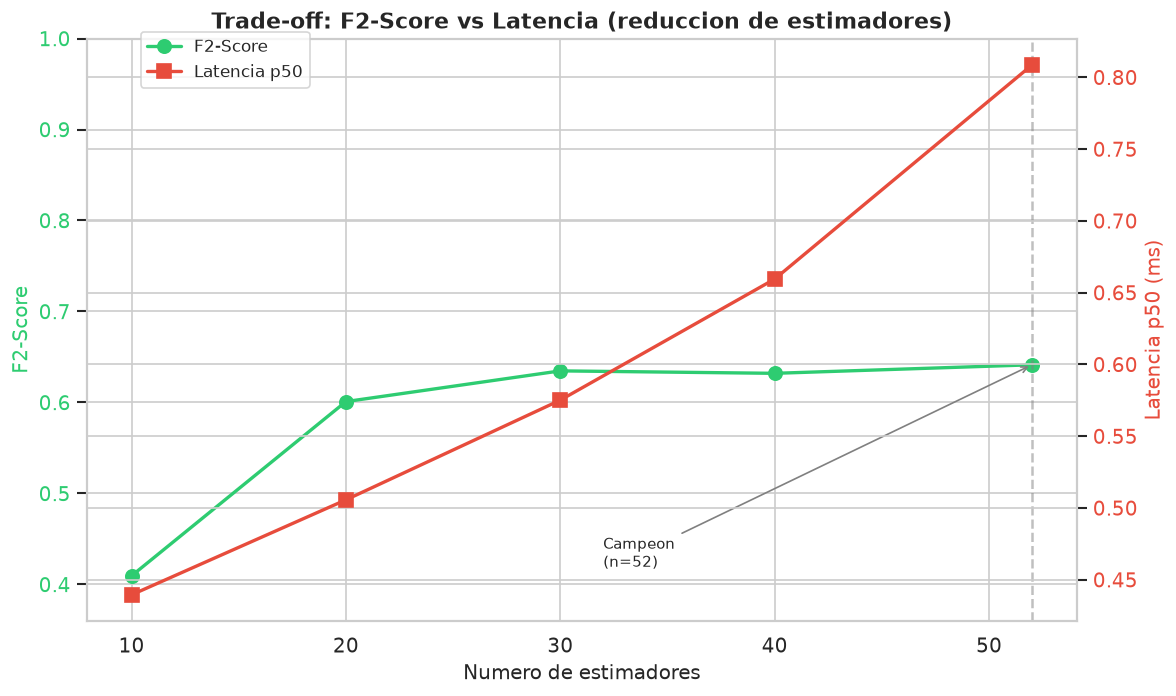

Guardado: tradeoff_f1_latencia.png


In [15]:
# 1 Reduccion de n_estimators en el core XGBoost del campeon
print('=== OPTIMIZACION: Reduccion de n_estimators ===')
print('Evaluar trade-off entre velocidad y calidad (F2) con menos arboles\n')

n_full = xgb_core.n_estimators
n_estimators_vals = [10, 20, 30, 40, n_full]
opt_results = []

for n_est in n_estimators_vals:
    # Prediccion usando solo los primeros n_est arboles (iteration_range)
    proba_r = xgb_core.predict_proba(X_test_xgb_scaled, iteration_range=(0, n_est))[:, 1]
    y_pred_r = (proba_r >= THRESHOLD_FINAL).astype(int)
    f2_r = fbeta_score(y_test, y_pred_r, beta=2, zero_division=0)

    # Medir latencia (batch=427)
    for _ in range(50):
        xgb_core.predict_proba(X_test_xgb_scaled, iteration_range=(0, n_est))
    lats = []
    for _ in range(500):
        t0 = time.perf_counter()
        xgb_core.predict_proba(X_test_xgb_scaled, iteration_range=(0, n_est))
        t1 = time.perf_counter()
        lats.append((t1-t0)*1000)

    p50 = np.percentile(lats, 50)
    opt_results.append({
        'n_estimators': n_est,
        'F2': f2_r,
        'Latencia_p50_ms': p50,
        'Speedup_vs_full': None
    })
    print(f'  n_est={n_est:>3d} | F2={f2_r:.4f} | p50={p50:.3f}ms')

# Speedup relativo al core completo del campeon
p50_full = [r['Latencia_p50_ms'] for r in opt_results if r['n_estimators']==n_full][0]
for r in opt_results:
    r['Speedup_vs_full'] = p50_full / r['Latencia_p50_ms']

df_opt = pd.DataFrame(opt_results)
df_opt.to_csv(os.path.join(OUT_DIR, 'optimizacion_n_estimators.csv'), index=False)
print('\nGuardado: optimizacion_n_estimators.csv')

# 2 Grafico trade-off F2 vs latencia
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(df_opt['n_estimators'], df_opt['F2'], 'o-', color='#2ecc71', linewidth=2, markersize=8, label='F2-Score')
ax1.set_xlabel('Numero de estimadores', fontsize=12)
ax1.set_ylabel('F2-Score', color='#2ecc71', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#2ecc71')
ax1.set_ylim(max(0, min(df_opt['F2'])-0.05), 1.0)

ax2 = ax1.twinx()
ax2.plot(df_opt['n_estimators'], df_opt['Latencia_p50_ms'], 's-', color='#e74c3c', linewidth=2, markersize=8, label='Latencia p50')
ax2.set_ylabel('Latencia p50 (ms)', color='#e74c3c', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.axvline(x=n_full, color='gray', linestyle='--', alpha=0.5)
ax1.annotate(f'Campeon\n(n={n_full})', xy=(n_full, df_opt[df_opt['n_estimators']==n_full]['F2'].values[0]),
             xytext=(n_full-20, df_opt['F2'].min()+0.01), fontsize=9,
             arrowprops=dict(arrowstyle='->', color='gray'))

fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95), fontsize=10)
plt.title('Trade-off: F2-Score vs Latencia (reduccion de estimadores)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'tradeoff_f1_latencia.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: tradeoff_f1_latencia.png')

# Resumen

In [16]:
# Generar tabla de optimizaciones probadas dinamicamente a partir de los resultados reales
print('='*70)
print('RESUMEN DE OPTIMIZACIONES PROBADAS')
print('='*70)

core_b1  = df_all[(df_all['Modelo']=='XGBoost_core_sklearn') & (df_all['Batch_Size']==1)].iloc[0]
onnx_b1  = df_all[(df_all['Modelo']=='XGBoost_core_ONNX') & (df_all['Batch_Size']==1)].iloc[0]
core_b427= df_all[(df_all['Modelo']=='XGBoost_core_sklearn') & (df_all['Batch_Size']==427)].iloc[0]
onnx_b427= df_all[(df_all['Modelo']=='XGBoost_core_ONNX') & (df_all['Batch_Size']==427)].iloc[0]
champ_b1 = df_all[(df_all['Modelo']=='XGBoost_campeon_sklearn') & (df_all['Batch_Size']==1)].iloc[0]
champ_b427=df_all[(df_all['Modelo']=='XGBoost_campeon_sklearn') & (df_all['Batch_Size']==427)].iloc[0]

speedup_b1 = core_b1['Latencia_p50_ms'] / onnx_b1['Latencia_p50_ms']
speedup_b427 = core_b427['Latencia_p50_ms'] / onnx_b427['Latencia_p50_ms']

mt_row = df_all[(df_all['Modelo']==f'XGBoost_core_ONNX_{n_threads}t') & (df_all['Batch_Size']==427)].iloc[0]
mt_speedup = core_b427['Latencia_p50_ms'] / mt_row['Latencia_p50_ms']

# Reduccion de estimadores: comparar core completo vs una version reducida
f2_full = df_opt[df_opt['n_estimators']==n_full]['F2'].values[0]
n_red = 30 if 30 in list(df_opt['n_estimators']) else int(df_opt['n_estimators'].iloc[1])
f2_red = df_opt[df_opt['n_estimators']==n_red]['F2'].values[0]
f2_degradacion = f2_full - f2_red
speedup_red = df_opt[df_opt['n_estimators']==n_red]['Speedup_vs_full'].values[0]

optim_summary = pd.DataFrame([
    {'Optimizacion': 'ONNX Runtime (single-thread)', 'Aplica a XGBoost': 'Si',
     'Resultado': f'Speedup {speedup_b1:.2f}x (batch=1), {speedup_b427:.2f}x (batch=427)',
     'Impacto en F2': 'Sin cambio (equivalente)', 'Recomendacion': 'Usar en produccion'},
    {'Optimizacion': 'ONNX Runtime (multi-thread)', 'Aplica a XGBoost': 'Si',
     'Resultado': f'Speedup {mt_speedup:.2f}x vs core sklearn',
     'Impacto en F2': 'Sin cambio', 'Recomendacion': 'Para alto throughput'},
    {'Optimizacion': f'Reduccion n_estimators ({n_red} vs {n_full})', 'Aplica a XGBoost': 'Si',
     'Resultado': f'Speedup {speedup_red:.2f}x',
     'Impacto en F2': f'Degradacion -{f2_degradacion:.4f}', 'Recomendacion': 'Solo si latencia es critica'},
    {'Optimizacion': 'TensorRT', 'Aplica a XGBoost': 'No',
     'Resultado': 'N/A - disenado para redes neuronales (CNN, Transformers)',
     'Impacto en F2': 'N/A', 'Recomendacion': 'No aplicable'},
    {'Optimizacion': 'torch.compile', 'Aplica a XGBoost': 'No',
     'Resultado': 'N/A - requiere modelos PyTorch',
     'Impacto en F2': 'N/A', 'Recomendacion': 'No aplicable'},
    {'Optimizacion': 'Batching', 'Aplica a XGBoost': 'Si',
     'Resultado': f'Throughput: {onnx_b1["Throughput_req_s"]:.0f} -> {onnx_b427["Throughput_req_s"]:.0f} req/s',
     'Impacto en F2': 'Sin cambio', 'Recomendacion': 'Usar batches >=32 en produccion'},
])
optim_summary.to_csv(os.path.join(OUT_DIR, 'resumen_optimizaciones.csv'), index=False)
print(optim_summary.to_string(index=False))

print('='*70)
print('RESUMEN EJECUTIVO - INFORME DE LATENCIA')
print('='*70)
print('')
print('1. LATENCIA DEL CAMPEON CALIBRADO (sklearn CPU, extremo a extremo):')
print(f'   - Batch=1:   p50={champ_b1["Latencia_p50_ms"]:.3f}ms | p95={champ_b1["Latencia_p95_ms"]:.3f}ms')
print(f'   - Batch=427: p50={champ_b427["Latencia_p50_ms"]:.3f}ms | p95={champ_b427["Latencia_p95_ms"]:.3f}ms')
print('   (incluye StandardScaler + 5 folds de calibracion isotonica + ensemble XGBoost)')
print('')
print('2. NUCLEO DE INFERENCIA (core XGBoost, componente optimizable con ONNX):')
print(f'   - Core sklearn batch=427: p50={core_b427["Latencia_p50_ms"]:.3f}ms')
print(f'   - Core ONNX    batch=427: p50={onnx_b427["Latencia_p50_ms"]:.3f}ms')
print('')
print('3. OPTIMIZACION ONNX (core vs core):')
print(f'   - Speedup batch=1:   {speedup_b1:.2f}x')
print(f'   - Speedup batch=427: {speedup_b427:.2f}x')
print(f'   - Equivalencia numerica verificada: max_diff={max_diff:.8f}')
print('')
print('4. ROBUSTEZ (pipeline campeon calibrado, con validacion de entrada de sklearn):')
print('   - NaN parciales (5%, 20%): StandardScaler los propaga y XGBoost los maneja nativamente -> 0% de error')
print('   - Valores extremos (x100) y todo-ceros: 0% de error')
print('   - Infinitos: rechazados por la validacion de entrada del pipeline (requieren limpieza previa en produccion)')
print('')
print('5. RECOMENDACION PARA PRODUCCION:')
print('   -> El campeon calibrado ofrece la probabilidad final (umbral de decision F2 = %.4f)' % THRESHOLD_FINAL)
print('   -> Para maximo throughput del nucleo, servir el core en ONNX Runtime con batches >=32')
print('   -> No se requiere GPU para este modelo (overhead no justificado)')
print('')

logger.info('='*60)
logger.info('FIN BENCHMARK DE LATENCIA')
logger.info(f'Artefactos guardados en: {OUT_DIR}')
logger.info('='*60)

RESUMEN DE OPTIMIZACIONES PROBADAS
                     Optimizacion Aplica a XGBoost                                                Resultado            Impacto en F2                   Recomendacion
     ONNX Runtime (single-thread)               Si              Speedup 29.66x (batch=1), 0.75x (batch=427) Sin cambio (equivalente)              Usar en produccion
      ONNX Runtime (multi-thread)               Si                            Speedup 1.14x vs core sklearn               Sin cambio            Para alto throughput
Reduccion n_estimators (30 vs 52)               Si                                            Speedup 1.41x      Degradacion -0.0067     Solo si latencia es critica
                         TensorRT               No N/A - disenado para redes neuronales (CNN, Transformers)                      N/A                    No aplicable
                    torch.compile               No                           N/A - requiere modelos PyTorch                      N/A        

# Lista de artefactos generados

In [17]:
print('=== ARTEFACTOS GENERADOS ===')
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f'  {f} ({size/1024:.1f} KB)')

print(f'\n  {log_path}')

=== ARTEFACTOS GENERADOS ===
  benchmark_latencia_completo.csv (5.9 KB)
  consumo_recursos.csv (0.2 KB)
  distribucion_latencias.png (90.5 KB)
  latencia_p50_p95_barras.png (142.3 KB)
  latencia_throughput.png (185.9 KB)
  optimizacion_n_estimators.csv (0.3 KB)
  resumen_comparativo.csv (0.5 KB)
  resumen_optimizaciones.csv (0.6 KB)
  rf_baseline_fe.onnx (341.5 KB)
  tradeoff_f1_latencia.png (100.4 KB)
  xgboost_optuna.onnx (136.2 KB)

  /workspaces/proyecto-zona-interes-Au/logs/benchmark_latencia.log
